# **NOVABANK ANALYTICS**

**Project:** Analytics Methods & Frameworks (Quantic MSBA)

**Objective:** Build a predictive model to identify term deposit conversion prospects, optimizing call center capacity allocation.

## Project Phases:
1. **Problem Framing** (Conversion prediction, not churn; telemarketing campaign context)
2. **Data Readiness** (Preprocessing, feature engineering, train/test split)
3. **Model Building** (Baseline + Improved models with GridSearchCV)
4. **Decision Framework** (Threshold optimization, scenario testing, pilot plan)
5. **Delivery** (Executive memo, slides, reproducible notebook)

## IMPORTS

In [45]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics & evaluation
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, 
    precision_recall_curve, ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## 1: LOAD & EXPLORE DATA

In [3]:
csv_url = "https://raw.githubusercontent.com/Uzorah/Quantic-Nova-Bank-Project/refs/heads/main/bank-additional-full.csv"
df = pd.read_csv(csv_url, sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
print("Shape of dataframe\n", df.shape)

Shape of dataframe
 (41188, 21)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Prercentage of Yes and No in target variable
df['y'].value_counts(normalize=True).map('{:.1%}'.format)

y
no     88.7%
yes    11.3%
Name: proportion, dtype: object

## 2. DATA PREPARATION

### _2.1 Feature Engineering and Cleaning_

In [7]:
# Dropping duration because of data leakage (it is only known after call)
df_clean = df.drop('duration', axis=1)

In [8]:
# Check for unknowns
for col in df.select_dtypes(include=['object', 'int64', 'float']).columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} ({unknown_count/len(df)*100:.1f}%)")

job: 330 (0.8%)
marital: 80 (0.2%)
education: 1731 (4.2%)
default: 8597 (20.9%)
housing: 990 (2.4%)
loan: 990 (2.4%)


In [9]:
# renaming unknowns
categorical_cols = [col for col in df_clean.select_dtypes(include='object').columns if col != 'y']
for col in categorical_cols:
    df_clean[col] = df_clean[col].replace('unknown', f'{col}_unknown')

### _2.2 Feature Encoding_

In [10]:
# one-hot encode only the non-target categoricals
df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

In [11]:
# Encode target variable
df_clean['y'] = (df_clean['y'] == 'yes').astype(int)

In [12]:
df_clean.shape

(41188, 53)

### _2.3 Data Splitting_

In [13]:
X = df_clean.drop('y', axis=1)
y = df_clean['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

### _2.4 Feature Scaling_

In [14]:
#scaling training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. BASELINE MODEL - LOGISTIC REGRESSION

### _3.1 Baseline Model Training_

In [15]:
# Train model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### _3.2 Baseline Predictions_

In [16]:
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

### _3.3 Baseline Metrics_

In [17]:
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_logreg):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_logreg):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_logreg):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_logreg):.4f}")

  Accuracy:  0.9012
  Precision: 0.6921
  Recall:    0.2213
  F1-Score:  0.3353
  ROC-AUC:   0.8033


## 4. IMPROVED MODELS

### _4.1 LightGBM_

In [66]:
lgb_param_grid = {
    'num_leaves': [20, 30, 40],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'min_child_samples': [5, 10],
}

lgb_grid = GridSearchCV(
    lgb.LGBMClassifier(
        random_state=42,
        class_weight='balanced',    
        verbosity=-1
    ),
    lgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

#### _4.1.1 LGB Training_

In [67]:
lgb_grid.fit(X_train_scaled, y_train)
lgb_best = lgb_grid.best_estimator_

print(f"\nBest LightGBM parameters: {lgb_grid.best_params_}")
print(f"Best LightGBM CV F1-Score: {lgb_grid.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best LightGBM parameters: {'learning_rate': 0.01, 'max_depth': 15, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 30}
Best LightGBM CV F1-Score: 0.7992


#### _4.1.2 LGB Predictions_

In [68]:
y_pred_lgb = lgb_best.predict(X_test_scaled)
y_pred_proba_lgb = lgb_best.predict_proba(X_test_scaled)[:, 1]

#### _4.1.3 LGB Metrics_

In [69]:
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lgb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lgb):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_lgb):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")

  Accuracy:  0.8462
  Precision: 0.3904
  Recall:    0.6501
  F1-Score:  0.4879
  ROC-AUC:   0.8139


### _4.2 Random Forest_

In [72]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [10, 20],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

#### _4.2.1 Random Forest Training_

In [73]:
rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_

print(f"\nBest RF parameters: {rf_grid.best_params_}")
print(f"Best RF CV F1-Score: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best RF CV F1-Score: 0.7974


#### _4.2.2 Random Forest Predictions_

In [74]:
y_pred_rf = rf_best.predict(X_test_scaled)
y_pred_proba_rf = rf_best.predict_proba(X_test_scaled)[:, 1]

#### _4.2.3 Random Forest Metrics_

In [75]:
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

  Accuracy:  0.8577
  Precision: 0.4142
  Recall:    0.6365
  F1-Score:  0.5018
  ROC-AUC:   0.8128


### _4.3 XGBoost_

#### _4.3.1 Hyperparameters_

In [76]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False,
                  scale_pos_weight=scale_pos_weight, eval_metric='logloss'),
    xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

#### _4.3.2 XGBoost Training_

In [77]:
xgb_grid.fit(X_train_scaled, y_train)
xgb_best = xgb_grid.best_estimator_

print(f"\nBest XGB parameters: {xgb_grid.best_params_}")
print(f"Best XGB CV F1-Score: {xgb_grid.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best XGB parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best XGB CV F1-Score: 0.7963


#### _4.3.3 XGBoost Predictions_

In [82]:
y_pred_xgb = xgb_best.predict(X_test_scaled)
y_pred_proba_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]

#### _4.3.4 XGBoost Metrics_

In [83]:
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

  Accuracy:  0.8412
  Precision: 0.3806
  Recall:    0.6523
  F1-Score:  0.4807
  ROC-AUC:   0.8126


### _4.4 Models & Probabilities_

In [84]:
models = {
    'Logistic Regression (Baseline)': logreg,
    'LightGBM (GridSearch)': lgb_best,
    'Random Forest (GridSearch)': rf_best,
    'XGBoost (GridSearch)': xgb_best
}

y_pred_probas = {
    'Logistic Regression (Baseline)': y_pred_proba_logreg,
    'LightGBM (GridSearch)': y_pred_proba_lgb,
    'Random Forest (GridSearch)': y_pred_proba_rf,
    'XGBoost (GridSearch)': y_pred_proba_xgb
}

## 5. MODEL COMPARISON & THRESHOLD ANALYSIS

### _5.1 Threshold Analysis: Precision vs Recall vs F1_

In [85]:
test_thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]

for model_name, model in models.items():
    y_pred_proba = y_pred_probas[model_name]
    
    print(f"\n{model_name}:")
    print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 50)
    
    for threshold in test_thresholds:
        y_pred_threshold = (y_pred_proba >= threshold).astype(int)
        
        if y_pred_threshold.sum() == 0:
            print(f"{threshold:<12.2f} {'N/A':<12} {'0.0000':<12} {'N/A':<12}")
        else:
            prec = precision_score(y_test, y_pred_threshold, zero_division=0)
            rec = recall_score(y_test, y_pred_threshold, zero_division=0)
            f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
            print(f"{threshold:<12.2f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")


Logistic Regression (Baseline):
Threshold    Precision    Recall       F1-Score    
--------------------------------------------------
0.30         0.5070       0.4404       0.4714      
0.40         0.5909       0.3175       0.4131      
0.50         0.6921       0.2213       0.3353      
0.60         0.7508       0.1731       0.2814      
0.70         0.7923       0.1042       0.1841      
0.75         0.7850       0.0603       0.1121      
0.80         0.8082       0.0424       0.0805      
0.85         0.8929       0.0180       0.0352      
0.90         N/A          0.0000       N/A         

LightGBM (GridSearch):
Threshold    Precision    Recall       F1-Score    
--------------------------------------------------
0.30         0.1605       0.8886       0.2719      
0.40         0.3047       0.7148       0.4272      
0.50         0.3904       0.6501       0.4879      
0.60         0.4474       0.6078       0.5154      
0.70         0.4686       0.5797       0.5183      
0.75     

### _5.2 Optimal Threshold by F1-Score_

In [86]:
fine_thresholds = np.arange(0.30, 0.91, 0.01)
optimal_thresholds = {}

for model_name, model in models.items():
    y_train_proba = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]
    
    best_f1 = 0
    best_threshold = 0.5
    
    for threshold in fine_thresholds:
        y_train_pred_thresh = (y_train_proba >= threshold).astype(int)
        if y_train_pred_thresh.sum() > 0:
            f1 = f1_score(y_train, y_train_pred_thresh, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
                
    y_test_proba = y_pred_probas[model_name]
    y_test_pred_optimal = (y_test_proba >= best_threshold).astype(int)
    
    test_f1 = f1_score(y_test, y_test_pred_optimal, zero_division=0)
    prec = precision_score(y_test, y_test_pred_optimal, zero_division=0)
    rec = recall_score(y_test, y_test_pred_optimal, zero_division=0)
    
    optimal_thresholds[model_name] = {
        'threshold': best_threshold,
        'test_f1_score': test_f1
    }
    
    print(f"\n{model_name}:")
    print(f"  Optimal Threshold: {best_threshold:.2f}")
    print(f"  Test F1-Score: {test_f1:.4f}")
    print(f"  Test Precision: {prec:.4f}")
    print(f"  Test Recall:    {rec:.4f}")



Logistic Regression (Baseline):
  Optimal Threshold: 0.30
  Test F1-Score: 0.4714
  Test Precision: 0.5070
  Test Recall:    0.4404

LightGBM (GridSearch):
  Optimal Threshold: 0.68
  Test F1-Score: 0.5175
  Test Precision: 0.4636
  Test Recall:    0.5855

Random Forest (GridSearch):
  Optimal Threshold: 0.65
  Test F1-Score: 0.5196
  Test Precision: 0.4742
  Test Recall:    0.5747

XGBoost (GridSearch):
  Optimal Threshold: 0.64
  Test F1-Score: 0.5159
  Test Precision: 0.4629
  Test Recall:    0.5826


### _5.3 ROC Curves for all Model_

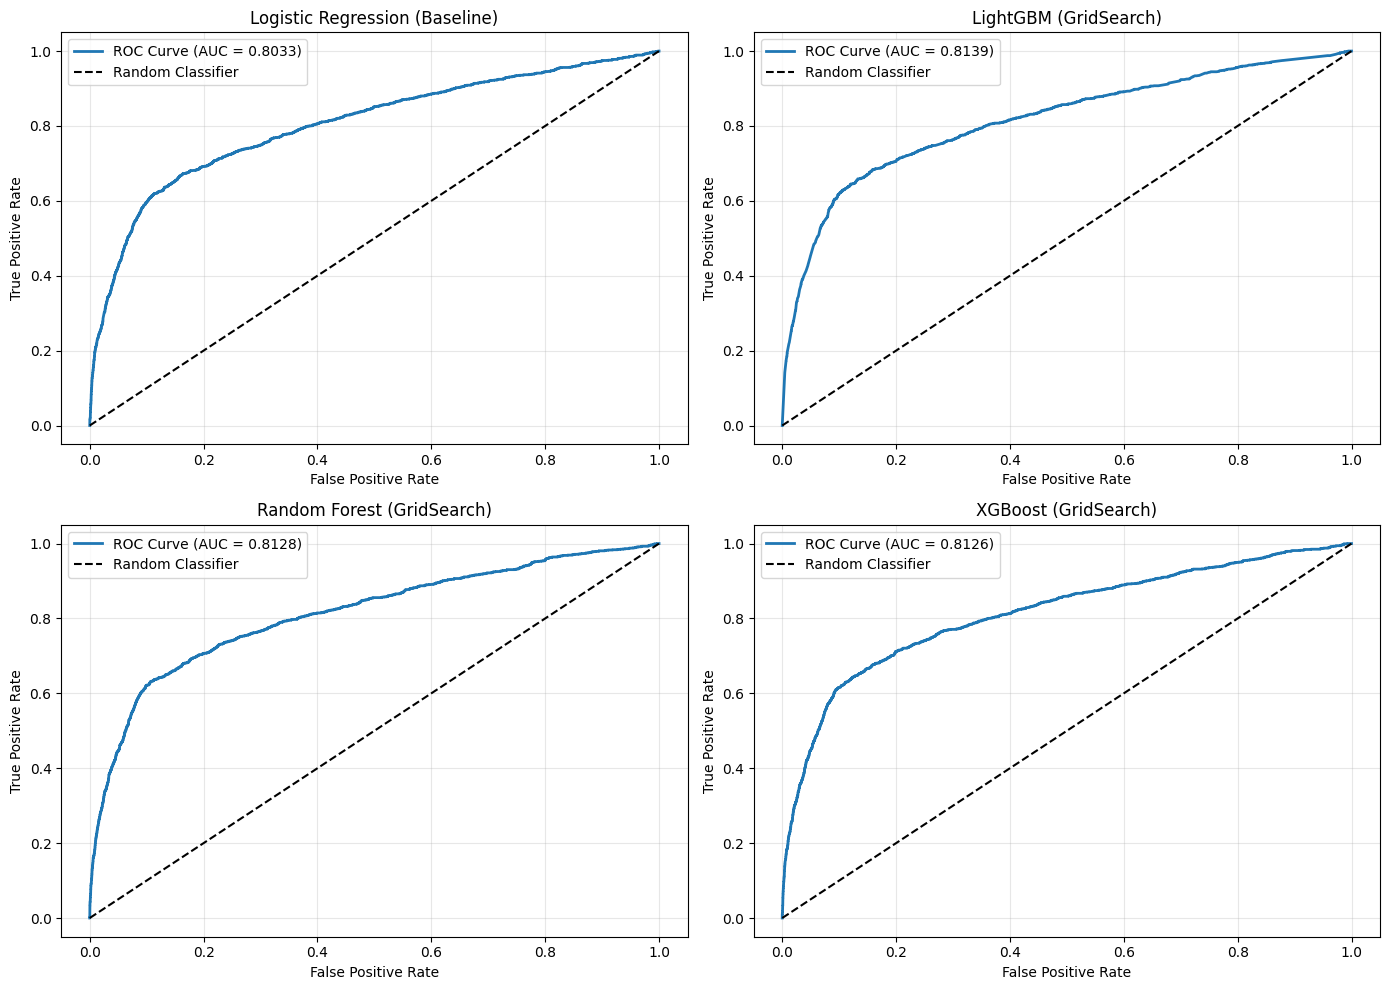

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred_proba = y_pred_probas[model_name]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    axes[idx].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
    axes[idx].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].set_title(f'{model_name}')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### _5.4 Precision-Recall Curves_

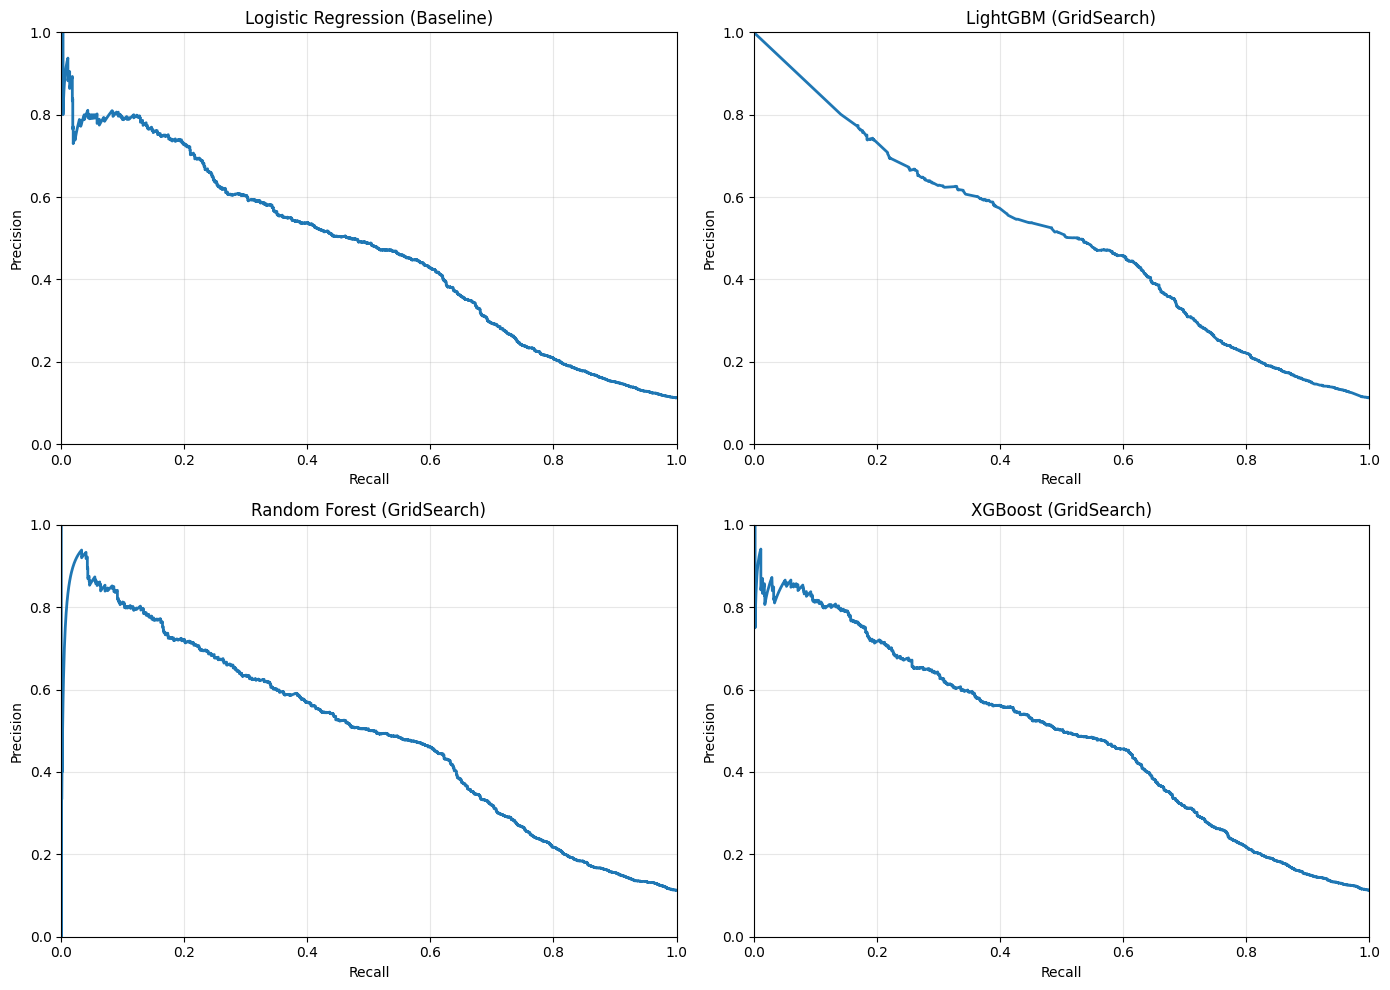

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred_proba = y_pred_probas[model_name]
    
    precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
    
    axes[idx].plot(recalls, precisions, linewidth=2)
    axes[idx].set_xlabel('Recall')
    axes[idx].set_ylabel('Precision')
    axes[idx].set_title(f'{model_name}')
    axes[idx].grid(alpha=0.3)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1])

plt.tight_layout()
plt.show()

### _5.5 Comparision Table_

In [89]:
comparison_results = []

for model_name, model in models.items():
    y_pred_proba = y_pred_probas[model_name]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    comparison_results.append({
        'Model': model_name,
        'Accuracy': f"{accuracy:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
        'ROC-AUC': f"{roc_auc:.4f}"
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df.style.format(precision=4).hide(axis='index')

Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression (Baseline),0.9012,0.6921,0.2213,0.3353,0.8033
LightGBM (GridSearch),0.8462,0.3904,0.6501,0.4879,0.8139
Random Forest (GridSearch),0.8577,0.4142,0.6365,0.5018,0.8128
XGBoost (GridSearch),0.8412,0.3806,0.6523,0.4807,0.8126


## 6. FEATURE IMPORTANCE

### _6.1 LGB Feature Importance_


                    feature  importance
                  euribor3m        1365
                        age         652
                   campaign         622
          contact_telephone         346
                      pdays         299
             cons.price.idx         282
                   previous         272
                nr.employed         216
                  month_oct         180
              cons.conf.idx         162
                 default_no         130
education_university.degree         120
            day_of_week_mon         101
               emp.var.rate          89
           poutcome_success          87


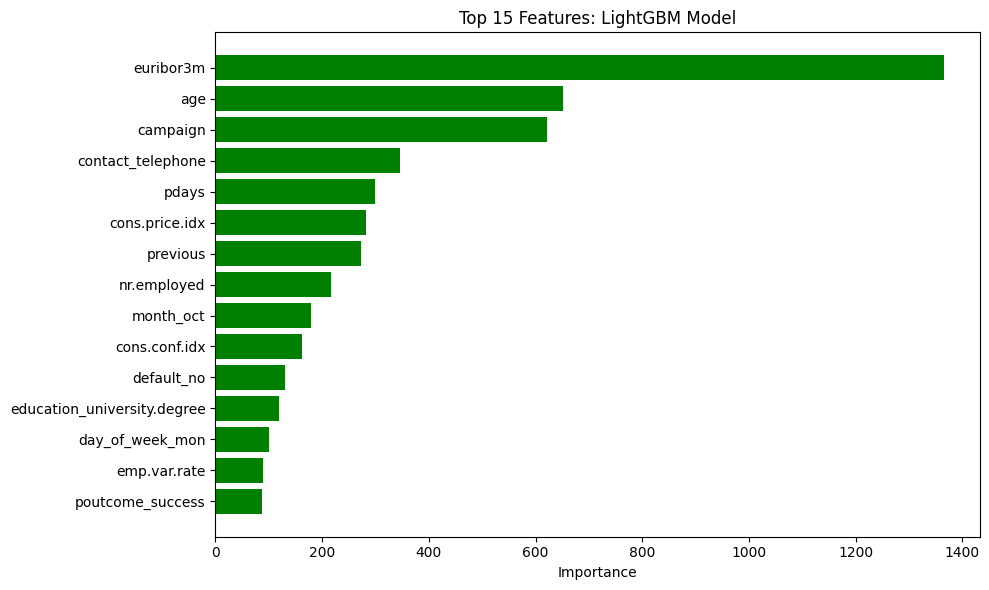

In [90]:
lgb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + lgb_feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features_lgb = lgb_feature_importance.head(15)
plt.barh(range(len(top_features_lgb)), top_features_lgb['importance'], color='green')
plt.yticks(range(len(top_features_lgb)), top_features_lgb['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features: LightGBM Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_lgb.png', dpi=300, bbox_inches='tight')
plt.show()

### _6.2 Random Forest Feature Importance_


             feature  importance
           euribor3m    0.184786
        emp.var.rate    0.169134
         nr.employed    0.135407
       cons.conf.idx    0.077825
               pdays    0.059176
      cons.price.idx    0.044128
                 age    0.040424
    poutcome_success    0.037759
           month_may    0.029240
   contact_telephone    0.026881
poutcome_nonexistent    0.020810
            campaign    0.019867
           month_oct    0.014166
            previous    0.014117
          default_no    0.013228


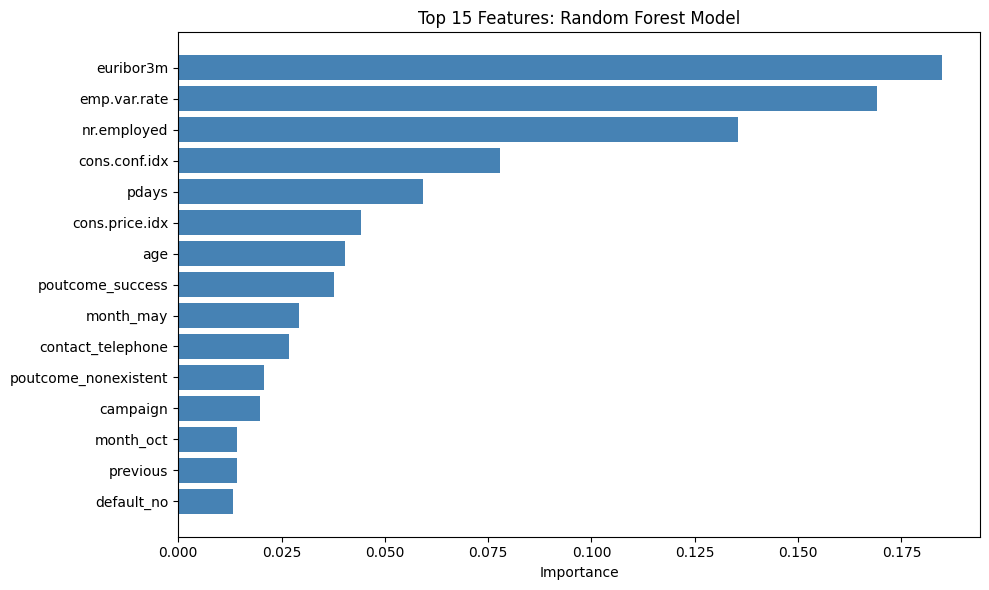

In [91]:
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + rf_feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features_rf = rf_feature_importance.head(15)
plt.barh(range(len(top_features_rf)), top_features_rf['importance'], color='steelblue')
plt.yticks(range(len(top_features_rf)), top_features_rf['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features: Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

### _6.3 XGBoost Feature Importance_


                feature  importance
            nr.employed    0.463233
           emp.var.rate    0.071174
          cons.conf.idx    0.054908
              month_oct    0.041470
              euribor3m    0.032955
       poutcome_success    0.024781
                  pdays    0.023581
             default_no    0.020408
         cons.price.idx    0.015631
      contact_telephone    0.015145
              month_may    0.012601
            job_retired    0.011703
   poutcome_nonexistent    0.011048
marital_marital_unknown    0.008871
               previous    0.008859


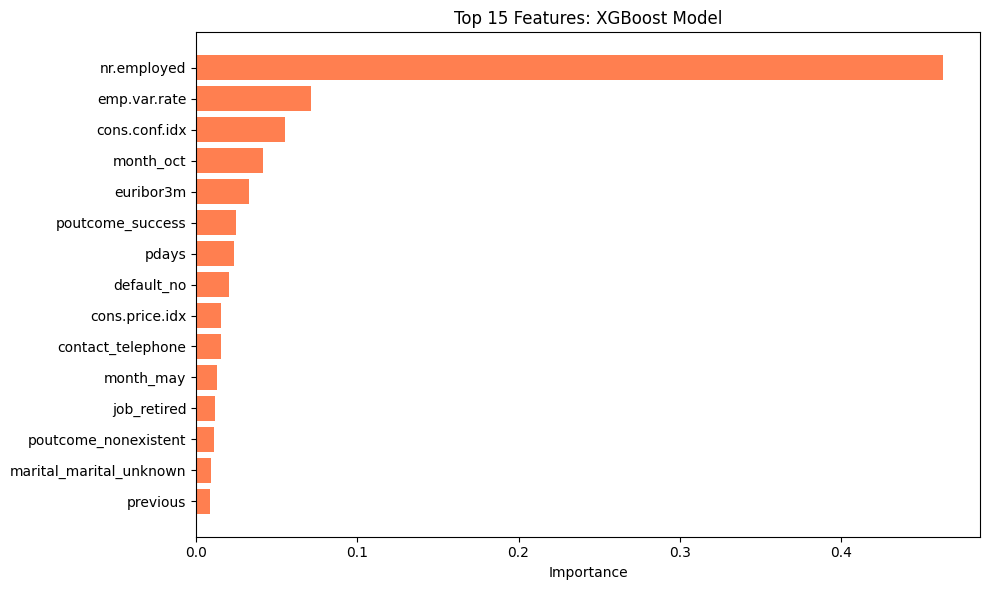

In [92]:
xgb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + xgb_feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features_xgb = xgb_feature_importance.head(15)
plt.barh(range(len(top_features_xgb)), top_features_xgb['importance'], color='coral')
plt.yticks(range(len(top_features_xgb)), top_features_xgb['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features: XGBoost Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=300, bbox_inches='tight')
plt.show()